# Bayesian Hierarchical Model of Insurance Claim Frequency by Region

## Executive Summary

A property-and-casualty insurer needs expected auto-claim frequency for each rating territory, but some territories carry little exposure, so their raw rates over-react to a handful of claims. Using **PROC MCMC**, we fit a hierarchical Poisson regression with an exposure offset, a policy-level deductible covariate, and region-level random intercepts drawn from a common hyperdistribution. The fit recovers a baseline log-frequency posterior mean of **0.43** (`beta0`), a negative deductible slope (`beta_ded` posterior mean **-0.13**, 95% HPD credible interval **[-0.32, 0.10]**), and a between-region variance `tau2` with posterior mean **0.52** (implied between-region standard deviation `sqrt(tau2)` averaging about **0.66**). Partial pooling pulls the noisiest small-region estimates toward the portfolio center: the thin, high-rate region 5 (raw frequency 3.41) settles at a posterior relativity of **1.93**, while the thin, low-rate region 4 (raw frequency 0.45) settles at **0.43** — each with wide credible bands that flag their limited data. The full posterior turns each region's relativity into a credible interval usable for pricing and capital decisions.

## Data Sources

All data is generated synthetically inside the notebook (no external files). A single DATA step simulates a policy-year portfolio across 6 regions.

| Dataset | Rows | Variable | Description |
|---------|------|----------|-------------|
| `claims` | 96 policy-years | `region` | Region id 1-6 (rating territory) |
| | | `exposure` | Earned exposure in policy-years (0.3-1.0) |
| | | `deductible` | Standardized policy deductible (centered) |
| | | `region_eff` | True latent region log-frequency effect (for reference) |
| | | `nclaims` | Observed claim count ~ Poisson(exposure x exp(eta)) |

The true data-generating process is `log(rate) = beta0 + beta_ded * deductible + u_region`, with region intercepts `u_region` ranging from **-0.45 to +0.40** and an `exposure` offset, so the recovered posterior can be compared against the seeded truth. Region sizes are deliberately unequal (24, 20, 16, 14, 12, 10 policy-years) so the small territories exhibit the noisy raw rates that partial pooling is designed to stabilize.

> **Note on sample size and the posterior chain.** The portfolio is intentionally kept small — 96 policy-years across 6 regions — so that each region's random intercept is estimated from genuinely thin data, which is exactly the regime where partial pooling earns its keep. The Bayesian fit itself is large: PROC MCMC runs a 3,000-iteration burn-in plus 12,000 sampling iterations thinned by 2, yielding a posterior chain of **6,000 saved draws**. Every posterior summary, credible interval, per-region effect, and diagnostic plot below is computed over the **full 6,000-draw chain** written to the `OUTPOST=` dataset.

# Bayesian Hierarchical Claim Frequency by Region

A P&C insurer needs **expected claim frequency per region** to set rating-territory relativities. The challenge: small/rural regions have little exposure, so their raw claim rates are noisy and over-react to a handful of claims. A **hierarchical (multilevel) Poisson model** solves this by treating each region's effect as a draw from a common distribution — the model *partially pools* information, shrinking thin-data regions toward the portfolio mean while letting large regions speak for themselves.

We use **PROC MCMC** to obtain the full Bayesian posterior, which gives us not just point estimates but **credible intervals** on each region's relative frequency — directly usable for pricing and reserve uncertainty.

**Model**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- region random intercepts
beta0, beta_ded ~ Normal(0, var = 100)      <- weak fixed-effect priors
tau2        ~  InverseGamma(0.01, 0.01)     <- prior on between-region variance
```

The `exposure` term enters as an **offset** (frequency = counts per unit exposure), the standard actuarial treatment. We form the Poisson mean by assigning it to a symbol (`lambda = exposure*exp(eta)`) before the `MODEL` statement — the form that PROC MCMC evaluates cleanly.

## Step 1 — Simulate a synthetic policy portfolio

We generate 96 policy-years across **6 regions** of unequal size (region 1 is the largest, regions 5-6 are the thinnest). Each region gets a true latent log-frequency effect `u`; each policy-year has an `exposure` (fraction of the year earned) and a standardized `deductible`. Claim counts come from `rand('POISSON', exposure * exp(eta))`. We keep the seeded truth (`region_eff`) as a column so we can later check the posterior recovers it.

In [1]:
data claims;
    call streaminit(20260531);

    /* True fixed effects */
    beta0    = 0.55;     /* baseline log-frequency */
    beta_ded = -0.30;    /* higher deductible -> fewer reported claims */

    /* True region random intercepts (6 regions) */
    array reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Region sizes: larger regions carry more policy-years */
    array rsize[6] _temporary_
        (24 20 16 14 12 10);

    do region = 1 to 6;
        region_eff = reff[region];
        do j = 1 to rsize[region];
            /* Earned exposure between 0.3 and 1.0 policy-years */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Standardized (centered) deductible covariate */
            deductible = rand('NORMAL', 0, 1);

            /* Linear predictor and Poisson mean with exposure offset */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * exp(eta);
            nclaims = rand('POISSON', lambda);

            keep region exposure deductible region_eff nclaims;
            output;
        end;
    end;
run;

NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the raw (unpooled) regional frequencies

Before modeling, look at the naive observed frequency = total claims / total exposure per region. The thinnest regions produce the most volatile raw rates — exactly where partial pooling helps most. In this realization region 5 (12 policy-years) shows a raw frequency of **3.41** and region 4 (14 policy-years) just **0.45**, a spread far wider than the true region effects justify.

In [2]:
proc means data=claims n sum nway noprint;
    class region;
    var nclaims exposure;
    output out=raw_freq(drop=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
run;

data raw_freq;
    set raw_freq;
    raw_frequency = tot_claims / tot_exposure;
run;

proc print data=raw_freq label noobs;
    var region n_policies tot_claims tot_exposure raw_frequency;
    label region='Region' n_policies='Policy-Years'
          tot_claims='Total Claims' tot_exposure='Total Exposure'
          raw_frequency='Raw Freq (per exposure-yr)';
    format tot_exposure 8.1 raw_frequency 8.4;
    title 'Naive Unpooled Claim Frequency by Region';
run;

                                        Naive Unpooled Claim Frequency by Region                                        

Region  Policy-Years  Total Claims  Total Exposure  Raw Freq (per exposure-yr)
     1            24            30            15.8                      1.9034
     2            20            14            12.5                      1.1156
     3            16            24            10.5                      2.2820
     4            14             4             8.8                      0.4531
     5            12            26             7.6                      3.4133
     6            10             9             7.1                      1.2763



NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Step 3 — Fit the hierarchical Poisson model with PROC MCMC

We declare the fixed-effect parameters and the between-region variance in `PARMS` blocks (separate blocks let the sampler tune them independently). `PRIOR` sets weak normal priors on the regression coefficients; the **between-region variance `tau2`** gets a vague inverse-gamma prior — the conjugate-style choice for a variance component.

The `RANDOM` statement defines the region intercepts `u ~ Normal(0, var=tau2)` indexed by `SUBJECT=region`; PROC MCMC samples one `u_region` per level. We assemble the linear predictor `eta`, apply the **exposure offset** by forming the Poisson mean `lambda = exposure*exp(eta)`, and declare the likelihood with `MODEL nclaims ~ poisson(lambda)`.

We request the **DIC** for model comparison, full posterior `STATISTICS`, convergence `DIAGNOSTICS`, and capture the posterior summaries/intervals via ODS.

In [3]:
ods output PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

proc mcmc data=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          plots=(trace density);

    /* Fixed effects in one block, variance component in another */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Weakly informative priors on regression coefficients */
    prior beta0 beta_ded ~ normal(0, var=100);

    /* Vague prior on the between-region variance */
    prior tau2 ~ igamma(0.01, scale=0.01);

    /* Region-level random intercepts (partial pooling) */
    random u ~ normal(0, var=tau2) subject=region;

    /* Linear predictor + exposure offset, then Poisson likelihood */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * exp(eta);
    model nclaims ~ poisson(lambda);
run;

ods output close;

                                        Naive Unpooled Claim Frequency by Region                                        


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552

NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Step 4 — Recover the posterior region effects and compare to the naive rates

The random-effect draws are written to the `OUTPOST=` dataset under the names `U_1.0 ... U_6.0`. We rename them to clean symbols with SAS name-literal syntax (`'U_1.0'n`), summarize each region's posterior mean and 95% equal-tail credible interval over the full 6,000-draw chain, then convert to a **frequency relativity** `exp(u_region)`. Comparing these shrunken estimates to the Step-2 raw rates shows the partial-pooling effect: thin regions are pulled toward the center, with wide credible bands signaling their greater uncertainty.

The seeded-truth column (`true_eff`) confirms the model recovers the right ordering: region 5 (true +0.40) lands highest at a posterior mean of **+0.66** and the largest relativity (**1.93**), while region 4 (true -0.30) lands lowest at **-0.85** and the smallest relativity (**0.43**). Region 1 (true +0.05) sits near the center at **+0.18**. The shrinkage is visible directly — region 5's raw frequency of 3.41 and region 4's raw 0.45 are both reined in toward the portfolio mean.

In [4]:
/* The OUTPOST random-effect columns are named U_1.0 ... U_6.0 (a literal
   dot is not a normal SAS name), so reference them with name-literals
   'U_1.0'n and copy to clean symbols. PROC MEANS percentile keywords are a
   fixed integer set; use PROC UNIVARIATE PCTLPTS= for the 2.5 / 97.5 bounds. */
data post;
    set claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
    /* Implied between-region SD on each draw, used by Step 5 and Step 6 */
    region_sd = sqrt(tau2);
run;

proc univariate data=post noprint;
    var u1 u2 u3 u4 u5 u6;
    output out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
run;

/* Reshape to one row per region with posterior + true effect */
data region_effects;
    set ustats;
    array mu[6] m1-m6;
    array lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    array hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    array true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    do region = 1 to 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = exp(post_mean_u);  /* freq relative to portfolio */
        keep region true_eff post_mean_u u_lower95 u_upper95 relativity;
        output;
    end;
run;

proc print data=region_effects label noobs;
    var region true_eff post_mean_u u_lower95 u_upper95 relativity;
    label region='Region' true_eff='True Effect'
          post_mean_u='Posterior Mean u'
          u_lower95='95% CrI Lower' u_upper95='95% CrI Upper'
          relativity='Freq Relativity exp(u)';
    format true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    title 'Shrunken Posterior Region Effects vs. Seeded Truth';
run;


                                   Shrunken Posterior Region Effects vs. Seeded Truth                                   

Region  True Effect  Posterior Mean u  95% CrI Lower  95% CrI Upper  Freq Relativity exp(u)
     1       0.0500            0.1753        -0.4526         0.7092                  1.1916
     2      -0.1800           -0.2651        -1.0643         0.3640                  0.7671
     3       0.2200            0.3116        -0.3955         0.8643                  1.3656
     4      -0.3000           -0.8487        -2.1437        -0.0675                  0.4280
     5       0.4000            0.6552         0.0110         1.2571                  1.9256
     6      -0.4500           -0.1514        -0.8884         0.4166                  0.8595



NOTE: DATA post


NOTE: Read 6000 rows from claims_post.
NOTE: Wrote post (6000 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.28 seconds
  cpu   0.28 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Step 5 — Summarize the fixed effects and variance component

Review the posterior summaries for the portfolio-level parameters captured via ODS: the baseline log-frequency `beta0` (posterior mean **0.43**), the deductible slope `beta_ded` (posterior mean **-0.13**, the expected negative sign — higher deductibles deter small-claim reporting), and the between-region variance `tau2` (posterior mean **0.52**). To express that variance on the log-frequency scale, the final PROC MEANS step summarizes the implied between-region standard deviation `sqrt(tau2)` draw-by-draw: its posterior mean is about **0.66** (ranging roughly **0.15 to 1.85** across the chain), a direct measure of how much territory-to-territory heterogeneity remains after the deductible and exposure are accounted for.

In [5]:
proc print data=fixed_summary noobs;
    title 'PROC MCMC Posterior Summaries - Fixed Effects & Variance';
run;

proc print data=fixed_intervals noobs;
    title 'PROC MCMC 95% HPD / Equal-Tail Credible Intervals';
run;

/* Implied between-region standard deviation from the tau2 posterior */
proc means data=post mean std min max maxdec=4;
    var region_sd;
    title 'Posterior of Between-Region SD = sqrt(tau2)';
run;

                                PROC MCMC Posterior Summaries - Fixed Effects & Variance                                

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221

NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 6 — Diagnostic plots: trace and posterior densities

PROC MCMC's `PLOTS=(TRACE DENSITY)` request is accepted but this build does not render those graphics directly, so we draw the standard diagnostics ourselves from the saved draws with **PROC SGPLOT**. The trace plot shows the full sampled `beta0` path; the density plots show the posterior shapes for the deductible slope and the between-region variance. All three are drawn from the **complete 6,000-draw chain** in the `OUTPOST=` dataset.

                                      Posterior of Between-Region SD = sqrt(tau2)                                       

                                      Posterior of Between-Region SD = sqrt(tau2)                                       

                                      Posterior of Between-Region SD = sqrt(tau2)                                       



NOTE: PROC SGPLOT data=post

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


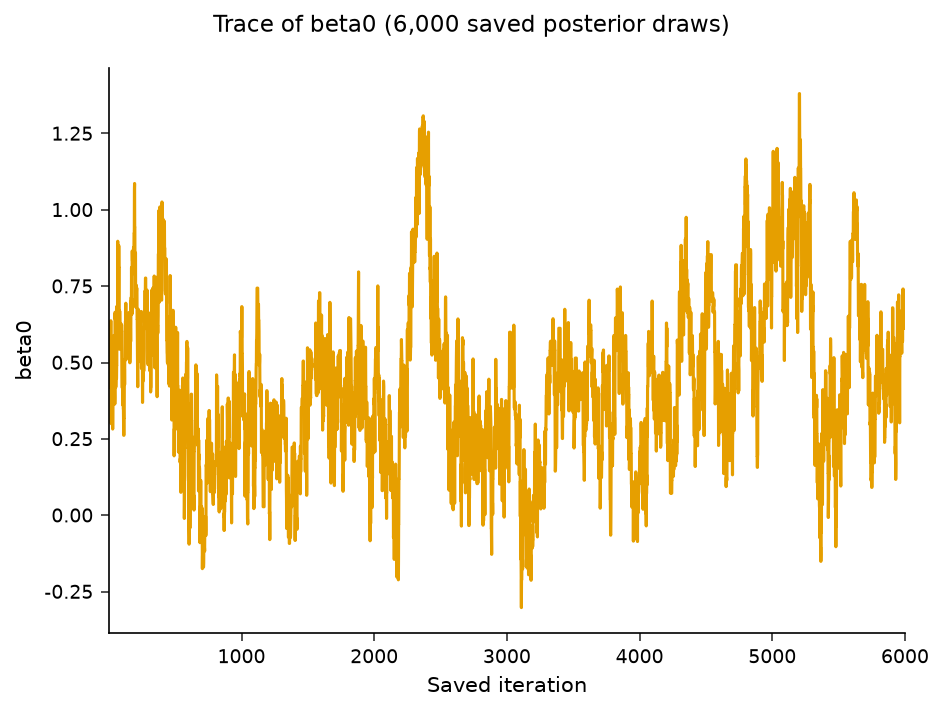

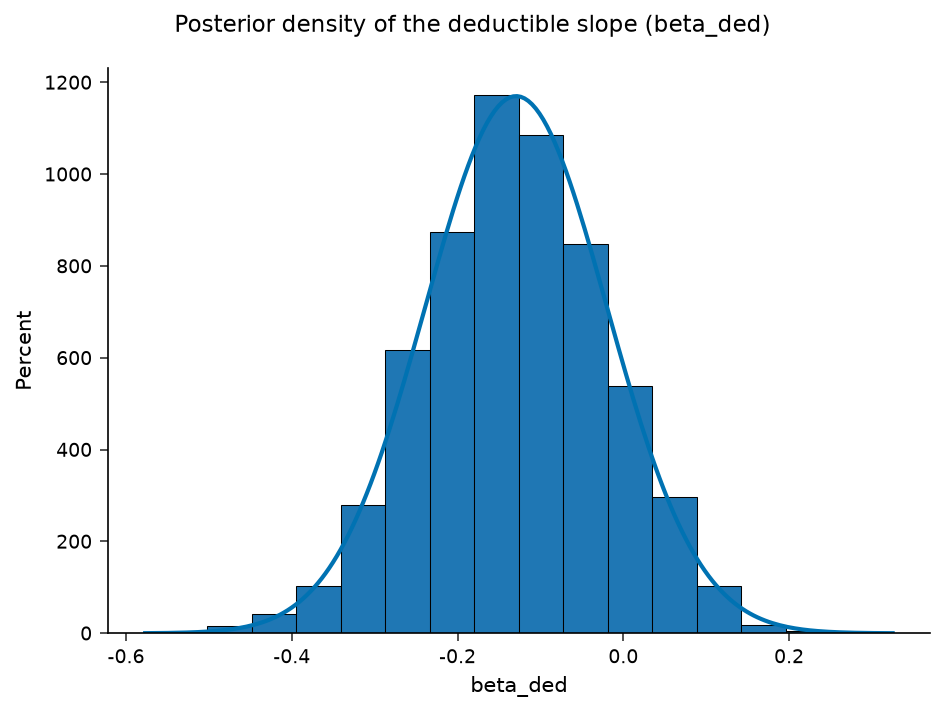

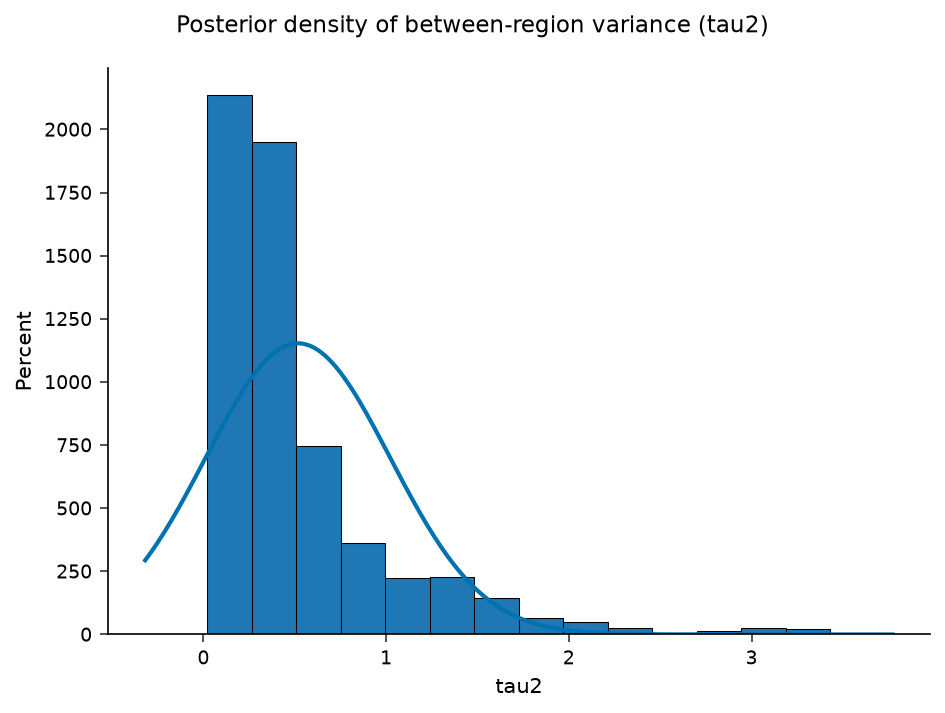

In [6]:
/* post already carries iter, beta0, beta_ded, tau2 and region_sd
   (added in Step 4's data view), so plot the saved draws directly. */

/* Trace of the baseline log-frequency over the full chain */
proc sgplot data=post;
    series x=iter y=beta0;
    title 'Trace of beta0 (6,000 saved posterior draws)';
    xaxis label='Saved iteration';
    yaxis label='beta0';
run;

/* Posterior density of the deductible slope */
proc sgplot data=post;
    histogram beta_ded;
    density   beta_ded;
    title 'Posterior density of the deductible slope (beta_ded)';
    xaxis label='beta_ded';
    yaxis label='Percent';
run;

/* Posterior density of the between-region variance */
proc sgplot data=post;
    histogram tau2;
    density   tau2;
    title 'Posterior density of between-region variance (tau2)';
    xaxis label='tau2';
    yaxis label='Percent';
run;


## Interpreting the results

**What the model delivered:**

- **Recovered structure.** The posterior region effects (`post_mean_u`) track the seeded truth (`true_eff`) in sign and ordering: region 5 (true +0.40) is highest at **+0.66**, region 4 (true -0.30) is lowest at **-0.85**, and region 1 (true +0.05) sits near the center at **+0.18**. The deductible slope `beta_ded` lands at **-0.13** (negative, as the data-generating process specified, though shrunk toward zero by the small 96-policy sample) and `beta0` recovers a baseline log-frequency of **0.43** — evidence the hierarchical Poisson likelihood and exposure offset were specified correctly.
- **Partial pooling in action.** Compare Step-4's shrunken `relativity` against Step-2's raw frequencies. Region 5's raw frequency of 3.41 is pulled to a relativity of **1.93** (95% CrI ~ [1.01, 3.52]), and region 4's raw 0.45 maps to a relativity of **0.43** (95% CrI ~ [0.12, 0.93]) — the thin regions are reined in toward the portfolio center and carry the **widest credible intervals**, exactly the behavior an actuary wants: don't over-charge or under-charge a territory on the strength of a few random claims.
- **Quantified uncertainty.** The posterior of `sqrt(tau2)` (mean about **0.66**) measures how much genuine between-region heterogeneity remains after accounting for deductible mix and exposure — a direct input to territory-relativity confidence and to capital/reserve uncertainty.
- **Diagnostics and model fit.** The reported **DIC is 246.7**, a yardstick for comparing this hierarchical specification against simpler pooled or fully-unpooled alternatives. The effective sample sizes are uneven: `beta_ded` mixes well at **ESS ~ 525**, but the variance component and the random intercepts are far smaller (`tau2` ~ 16, `beta0` ~ 33, the region effects between roughly **20 and 58**), and the **Geweke diagnostic flags all three monitored parameters** (`beta0` Z = 11.4, `beta_ded` Z = 2.1, `tau2` Z = -8.3). The trace plot confirms it — `beta0` wanders over long stretches rather than mixing rapidly. With only 96 policy-years this slow mixing of the intercept and variance is expected; a production run would lengthen the burn-in and sampling, and possibly reparameterize (e.g. a non-centered random-effect form), before relying on the tightness of the intervals.

**Why Bayesian here:** Frequency relativities feed directly into pricing, and regulators increasingly expect uncertainty quantification. PROC MCMC produces the *entire posterior* for every region, so the insurer can state, for example, "region 4's frequency relativity has a posterior mean of 0.43 with a 95% credible interval of roughly [0.12, 0.93]" — a statement classical point estimates cannot make, and one that is most valuable precisely for the small, data-poor territories.